# Neural Network in GW detectability

Moving from the problem in Exercise 20, let's see if we can predict detectability training a neural network.

In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.12.0
GPU: []


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
np.random.seed(1234)
tf.random.set_seed(1234)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [40]:
def builder(input_dim, neurons):
    init = keras.initializers.glorot_uniform(seed=1234)
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        keras.layers.Dense(neurons, activation='relu', kernel_initializer=init, kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dense(1, activation='sigmoid', kernel_initializer=init)
    ])

    model.compile(
        optimizer=keras.optimizers.legacy.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

# learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 50:
        return lr
    else:
        return lr * tf.math.exp(-0.05)
        
 # class weight function
def class_weight(y):
    from sklearn.utils import class_weight
    class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
    return dict(enumerate(class_weights))

# The NN
def trainnetwork(input_train, output_train, input_val, output_val, epochs, neurons, batch_size, filename):

    # build and compile the model
    model = builder(input_train.shape[1], neurons)
    
    # fit the model
    history = model.fit(
            input_train, 
            output_train,   
            validation_data=(input_val, output_val),
            batch_size=batch_size,       
            epochs=epochs,  
            class_weight = class_weight(output_train), 
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=50,
                    restore_best_weights=True),
                keras.callbacks.ModelCheckpoint(
                    filepath=filename,
                    save_weights_only=False,
                    monitor='val_loss',
                    mode='min',
                    save_best_only=True),
                keras.callbacks.LearningRateScheduler(scheduler),
                keras.callbacks.TensorBoard(log_dir="logs" + filename.split('.h5')[0], histogram_freq=1) if filename != False else None
            ],
            shuffle=True,
            verbose=0            #shorter output
        )
    
    return model, history

In [7]:
import h5py

path = "/Users/ffara/Desktop/LML/astrostatistics_bicocca_2025/exercise/sample_2e7_design_precessing_higherordermodes_3detectors.h5"
with h5py.File(path, 'r') as f:
    fin = {key: f[key][()] for key in f.keys()}

In [8]:
N_lim = 1000000
N_epochs = 100

data = {k: v[:N_lim] for k, v in fin.items()}
len(data['q'])

1000000

In [9]:
Y = data['det']

X = np.column_stack([
    data['q'],
    data['mtot'],
    data['iota'],
    data['ra'],
    data['dec'],
    data['psi'],
    data['chi1x'],
    data['chi1y'],
    data['chi1z'],
    data['chi2x'],
    data['chi2y'],
    data['chi2z'],
    data['z'],
    # data['snr'],
])

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [11]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Cross Validation

In [12]:
from sklearn.model_selection import KFold

In [25]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
best_auc = 0
best_params = {}

param_grid = {
    'neurons': [32, 64, 128],
    'batch_size': [128, 256, 512]
}

In [ ]:
print("Starting Cross-Validation...")

for neurons in param_grid['neurons']:
    for batch_size in param_grid['batch_size']:
        print(f"\nTest configuration: Neurons={neurons}, Batch Size={batch_size}")
        fold_aucs = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            X_train_cv, X_val_cv = X_train[train_idx], X_train[val_idx]
            Y_train_cv, Y_val_cv = Y_train[train_idx], Y_train[val_idx]

            model = builder(X_train_cv.shape[1], neurons)
            history = model.fit(
                X_train_cv, Y_train_cv,
                validation_data=(X_val_cv, Y_val_cv),
                batch_size=batch_size,
                epochs=50,
                class_weight=class_weight(Y_train_cv),
                verbose=0
            )

            val_auc = history.history['val_auc'][-1]
            fold_aucs.append(val_auc)

        mean_auc = np.mean(fold_aucs)
        print(f"-> Mean Validation AUC: {mean_auc:.4f}")

        if mean_auc > best_auc:
            best_auc = mean_auc
            best_params = {'neurons': neurons, 'batch_size': batch_size}

In [27]:
print(f"\nBest Configuration: {best_params} with AUC = {best_auc:.4f}")


Best Configuration: {'neurons': 64, 'batch_size': 128} with AUC = 0.9898


### Final Train

Notice that we can load previous trained NN or retrain.

In [ ]:
# NN = keras.models.load_model("trained22.h5")
# print(NN.summary())

In [28]:
X_train_final, X_val_final, Y_train_final, Y_val_final = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

In [41]:
model, history = trainnetwork(X_train_final, Y_train_final, X_val_final, Y_val_final, N_epochs, neurons=64, batch_size=128, filename="trained22.h5")

print(history.history.keys())

dict_keys(['loss', 'auc', 'precision', 'recall', 'val_loss', 'val_auc', 'val_precision', 'val_recall', 'lr'])


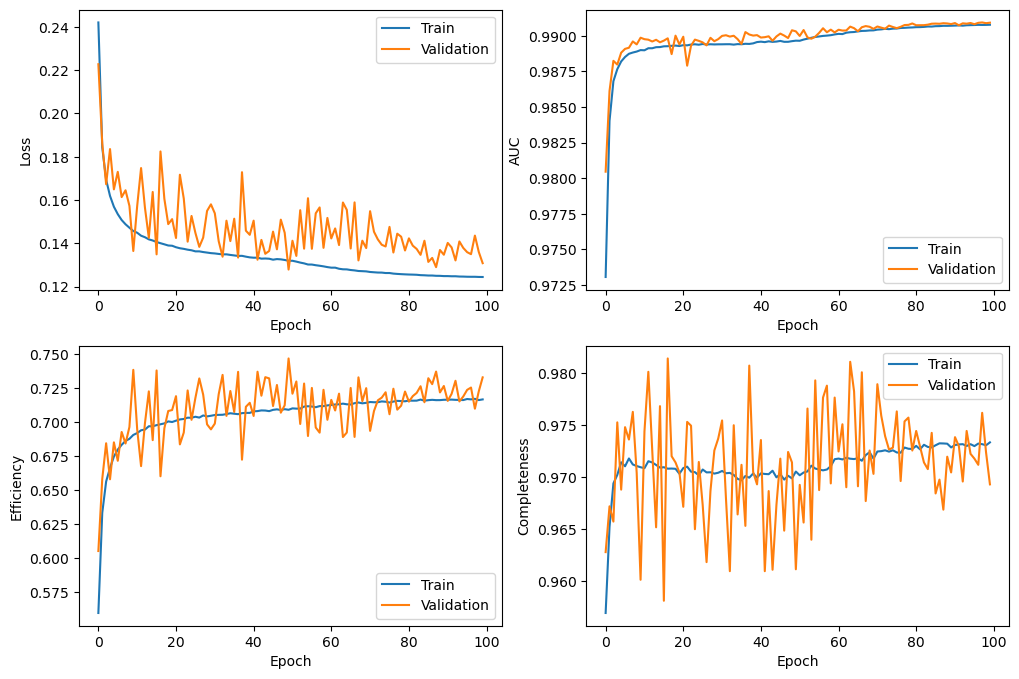

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0][0].plot(history.history['loss'], label='Train')
ax[0][0].plot(history.history['val_loss'], label='Validation')
ax[0][0].set_xlabel("Epoch")
ax[0][0].set_ylabel("Loss")
ax[0][0].legend()

ax[0][1].plot(history.history['auc'], label='Train')
ax[0][1].plot(history.history['val_auc'], label='Validation')
ax[0][1].set_xlabel("Epoch")
ax[0][1].set_ylabel("AUC")
ax[0][1].legend()

ax[1][0].plot(history.history['precision'], label='Train')
ax[1][0].plot(history.history['val_precision'], label='Validation')
ax[1][0].set_xlabel("Epoch")
ax[1][0].set_ylabel("Efficiency")
ax[1][0].legend()

ax[1][1].plot(history.history['recall'], label='Train')
ax[1][1].plot(history.history['val_recall'], label='Validation')
ax[1][1].set_xlabel("Epoch")
ax[1][1].set_ylabel("Completeness")
ax[1][1].legend()

tight_layout = True

7813/7813 [==============================] - 3s 382us/step


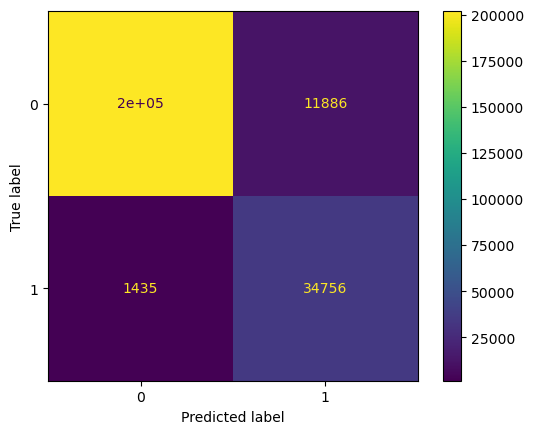

In [43]:
# Y_pred = NN.predict(X_test)

Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [44]:
accuracy = cm.diagonal().sum() / cm.sum()
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9467


In [45]:
completeness = cm[1,1] / (cm[1,0] + cm[1,1])
contamination = cm[0,1] / (cm[0,0] + cm[0,1])

print(f"Completeness: {completeness:.4f}")
print(f"Contamination: {contamination:.4f}")

Completeness: 0.9603
Contamination: 0.0556
